##EDA of xBD Dataset
1.

Tiling Convention Used: 0 = Background, 1 = No Damage, 2 = Minor Damage, 3 = Major Damage, 4 = Destroyed

In [49]:
import os
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from collections import defaultdict

1. Ensure same number of image and mask tiles, correct dimensions, and valid class values

In [3]:
# Change Directory Names if needed
img_dir = "./tiles/images"
mask_dir = "./tiles/masks"

In [4]:
class_names = {
    0: "Background",
    1: "No Damage",
    2: "Minor Damage",
    3: "Major Damage",
    4: "Destroyed"
}


In [5]:
# Validates Same Number of Images and Masks
imgs = sorted(os.listdir(img_dir))
masks = sorted(os.listdir(mask_dir))
print("Total Image Tiles:", len(imgs))
print("Total Mask Tiles:", len(masks))

Total Image Tiles: 13692
Total Mask Tiles: 13692


In [6]:
# Validate Pairing (Same name)
for i in range(min(4, len(masks))):
    print(f"Image: {imgs[i]} | Mask: {masks[i]}")

Image: guatemala-volcano_00000000_post_disaster_0_0.tif | Mask: guatemala-volcano_00000000_post_disaster_0_0.tif
Image: guatemala-volcano_00000000_post_disaster_512_0.tif | Mask: guatemala-volcano_00000000_post_disaster_512_0.tif
Image: guatemala-volcano_00000000_post_disaster_512_512.tif | Mask: guatemala-volcano_00000000_post_disaster_512_512.tif
Image: guatemala-volcano_00000000_pre_disaster_0_0.tif | Mask: guatemala-volcano_00000000_pre_disaster_0_0.tif


In [7]:
# Validate all mask files have a matching image tile
img_set = set(imgs)
mask_set = set(masks)

missing_images = sorted(mask_set - img_set)
missing_masks = sorted(img_set - mask_set)

print("Masks without matching image:", len(missing_images))
print("Images without matching mask:", len(missing_masks))

Masks without matching image: 0
Images without matching mask: 0


In [8]:
# Check Mask Values
unique_vals = set()

for f in masks[:100]:
    m = np.array(Image.open(os.path.join(mask_dir, f)))
    unique_vals.update(np.unique(m).tolist())

print("Unique mask values in first 100 masks:", sorted(unique_vals))

Unique mask values in first 100 masks: [0, 1, 2, 3, 4]


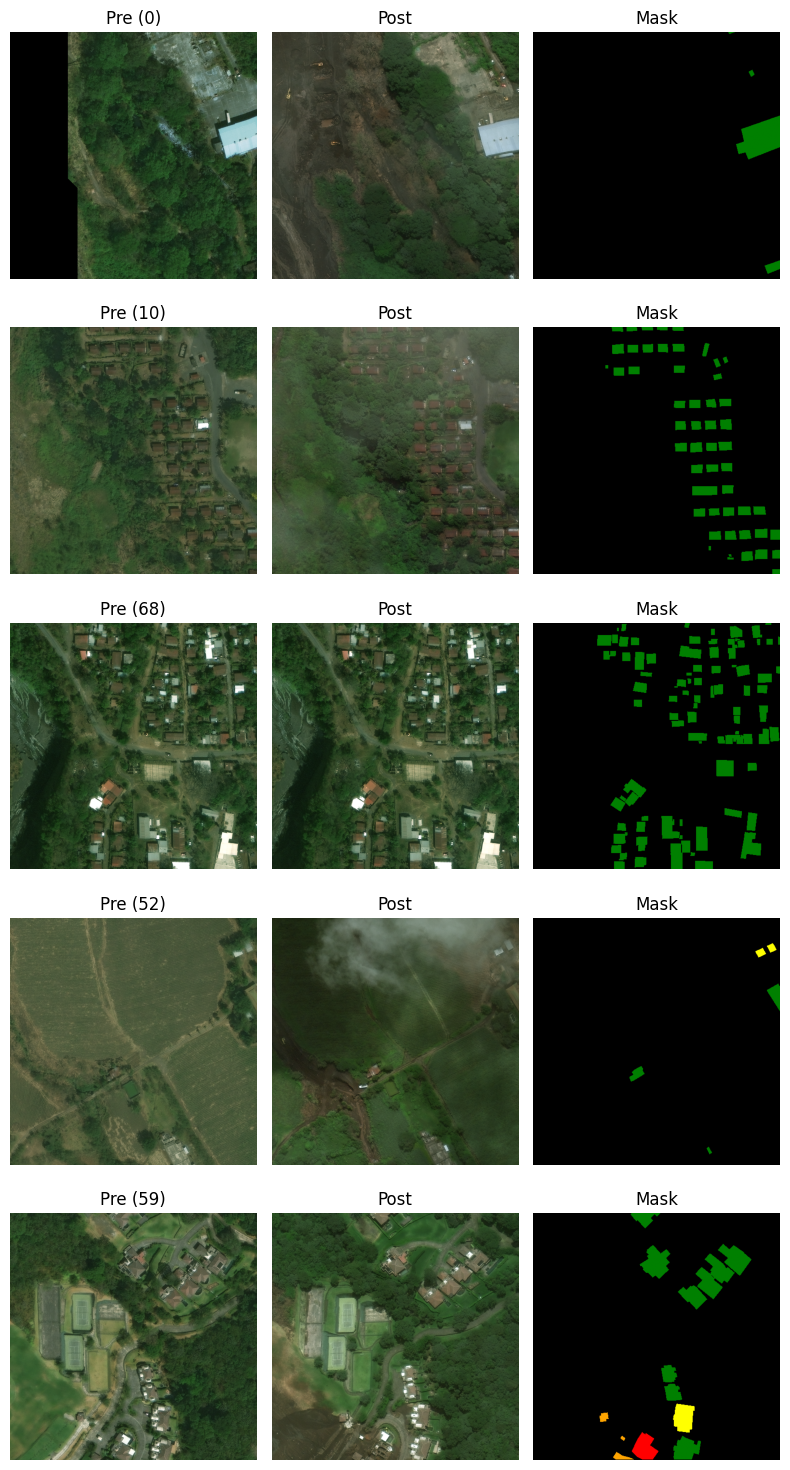

In [43]:
import matplotlib.pyplot as plt
import numpy as np

num_samples = 5
indices = [0, 10, 68, 52, 59]

fig, ax = plt.subplots(num_samples, 3, figsize=(8, 3 * num_samples))

for row, idx in enumerate(indices):
    post_name = imgs[idx]
    pre_name = post_name.replace("post", "pre")

    pre = Image.open(os.path.join(img_dir, pre_name))
    post = Image.open(os.path.join(img_dir, post_name))
    mask = Image.open(os.path.join(mask_dir, post_name))

    # Pre
    ax[row, 0].imshow(pre)
    ax[row, 0].set_title(f"Pre ({idx})")
    ax[row, 0].axis("off")

    # Post
    ax[row, 1].imshow(post)
    ax[row, 1].set_title("Post")
    ax[row, 1].axis("off")

    # Mask
    import matplotlib.colors as mcolors

    cmap = mcolors.ListedColormap([
        "black",      # 0 background
        "green",      # 1 no damage
        "yellow",     # 2 minor
        "orange",     # 3 major
        "red"         # 4 destroyed
    ])

    ax[row, 2].imshow(mask, cmap=cmap, vmin=0, vmax=4)
    ax[row, 2].set_title("Mask")
    ax[row, 2].axis("off")

plt.tight_layout()
plt.show()

In [12]:
# Display Pixel-Wise Class Distribution
pixel_counts = Counter()

for f in masks:
    m = np.array(Image.open(os.path.join(mask_dir, f)))
    vals, counts = np.unique(m, return_counts=True)
    for v, c in zip(vals, counts):
        pixel_counts[v] += c

print("Pixel counts by class:")
for cls in sorted(class_names.keys()):
    print(f"{cls} ({class_names[cls]}): {pixel_counts.get(cls, 0)}")

Pixel counts by class:
0 (Background): 3258249517
1 (No Damage): 287893139
2 (Minor Damage): 15076019
3 (Major Damage): 19138232
4 (Destroyed): 8918741


In [13]:
counts = {
    0: 3258249517,
    1: 287893139,
    2: 15076019,
    3: 19138232,
    4: 8918741}

class_names = {
    0: "Background",
    1: "No Damage",
    2: "Minor",
    3: "Major",
    4: "Destroyed"
}

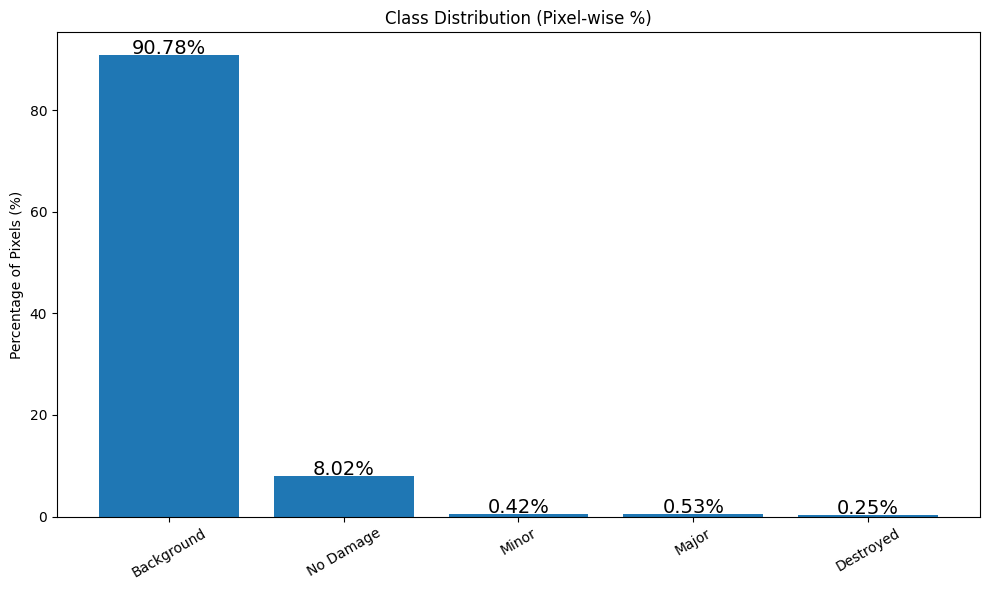

In [16]:
total_pixels = sum(counts.values())
percentages = {k: (v / total_pixels) * 100 for k, v in counts.items()}

# Sort by class index
classes = sorted(percentages.keys())
values = [percentages[c] for c in classes]
labels = [class_names[c] for c in classes]

# Plot
plt.figure(figsize=(10, 6))
plt.bar(labels, values)

plt.ylabel("Percentage of Pixels (%)")
plt.title("Class Distribution (Pixel-wise %)")
plt.xticks(rotation=30)

# Percentage Annotation
for i, v in enumerate(values):
    plt.text(i, v + 0.2, f"{v:.2f}%",
             ha='center', fontsize =14)

plt.tight_layout()
plt.show()

In [44]:
labeled_tiles = 0
damage_tiles = 0
background_only_tiles = 0

for f in masks:
    m = np.array(Image.open(os.path.join(mask_dir, f)))
    if np.any(m > 0):
        labeled_tiles += 1
    else:
        background_only_tiles += 1

    if np.any(m > 1):
        damage_tiles += 1

# Removed in Preprocessing
print("Background-only tiles:", background_only_tiles)
print("Tiles with any labeled building:", labeled_tiles)
print("Tiles with actual damage (classes 2/3/4):", damage_tiles)
print("Total tiles:", len(masks))

print("Labeled tiles (%):", round(labeled_tiles / len(masks) * 100, 3))
print("Damaged tiles (%):", round(damage_tiles / len(masks) * 100, 3))

Background-only tiles: 0
Tiles with any labeled building: 13692
Tiles with actual damage (classes 2/3/4): 3891
Total tiles: 13692
Labeled tiles (%): 100.0
Damage tiles (%): 28.418


Tile presence counts:
0 (Background): 13692
1 (No Damage): 11967
2 (Minor): 2027
3 (Major): 2030
4 (Destroyed): 1959


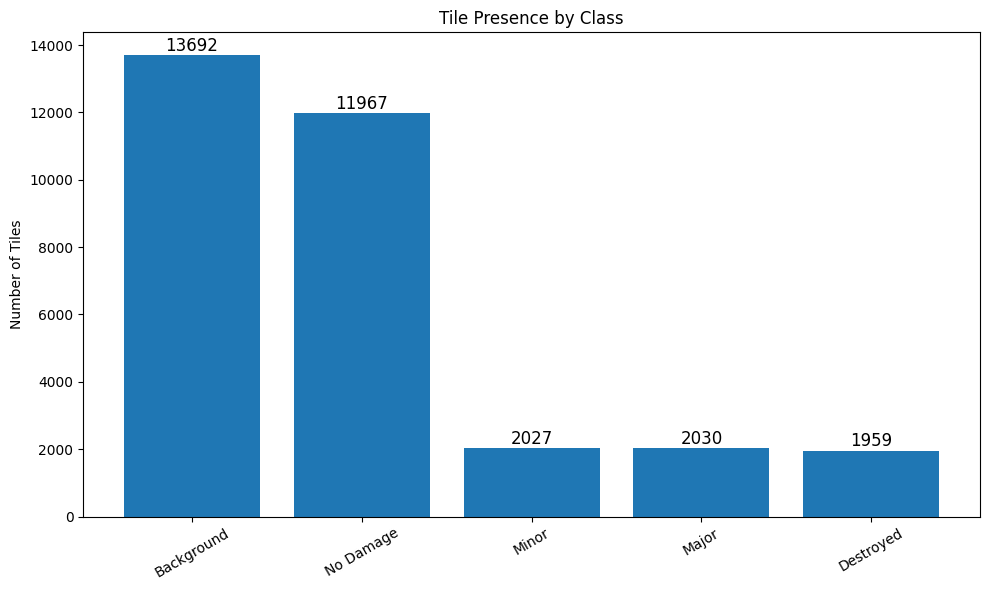

In [18]:
# Distrbution if Tile Count (Not really necessary, we can delete later)
tile_presence = Counter()

for f in masks:
    m = np.array(Image.open(os.path.join(mask_dir, f)))
    present_classes = np.unique(m)
    for cls in present_classes:
        tile_presence[int(cls)] += 1

print("Tile presence counts:")
for cls in sorted(class_names.keys()):
    print(f"{cls} ({class_names[cls]}): {tile_presence.get(cls, 0)}")

presence_labels = [class_names[c] for c in sorted(class_names.keys())]
presence_values = [tile_presence.get(c, 0) for c in sorted(class_names.keys())]

plt.figure(figsize=(10, 6))
plt.bar(presence_labels, presence_values)
plt.ylabel("Number of Tiles")
plt.title("Tile Presence by Class")
plt.xticks(rotation=30)

for i, v in enumerate(presence_values):
    plt.text(i, v + max(presence_values) * 0.01, str(v), ha="center", fontsize=12)

plt.tight_layout()
plt.show()

Could be useful for presentation later,
Tile contains [0, 0, 0, 1, 1, 2...]  size 512 x 512


In [ ]:
# Investigation of Damage by Disaster Type

In [45]:
def extract_disaster_type(filename):
    return filename.split("_")[0]

disaster_counts = Counter()

for f in imgs:
    disaster = extract_disaster_type(f)
    disaster_counts[disaster] += 1

print("Tile count per disaster:")
for k, v in disaster_counts.items():
    print(k, v)

Tile count per disaster:
guatemala-volcano 84
hurricane-florence 1592
hurricane-harvey 1912
hurricane-matthew 1376
hurricane-michael 2352
mexico-earthquake 904
midwest-flooding 1316
palu-tsunami 754
santa-rosa-wildfire 1442
socal-fire 1960


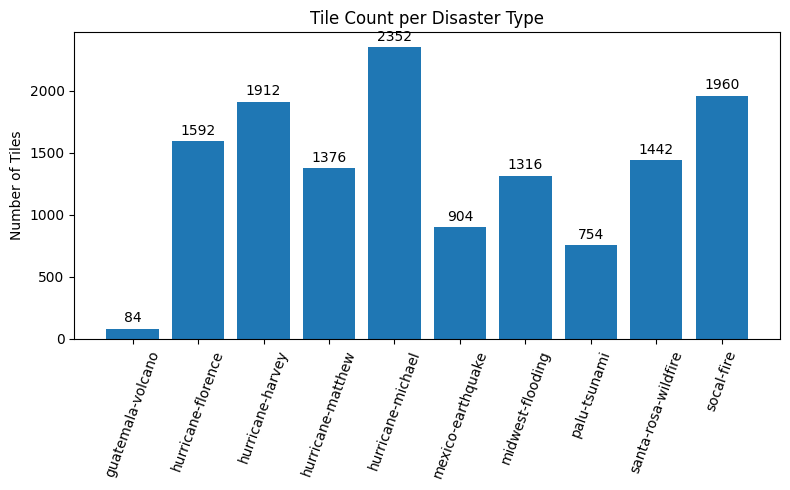

(None, None)

In [62]:
labels = list(disaster_counts.keys())
values = list(disaster_counts.values())

plt.figure(figsize=(8, 5))
plt.bar(labels, values)
plt.xticks(rotation = 70)
plt.title("Tile Count per Disaster Type")
plt.ylabel("Number of Tiles")

for i, v in enumerate(values):
    plt.text(i, v + 50, str(v), ha='center')

plt.tight_layout(), plt.show()

In [50]:
damage_per_disaster = defaultdict(int)
total_per_disaster = defaultdict(int)

for f in masks:
    disaster = extract_disaster_type(f)
    m = np.array(Image.open(os.path.join(mask_dir, f)))
    total_per_disaster[disaster] += 1

    if np.any(m > 1):
        damage_per_disaster[disaster] += 1

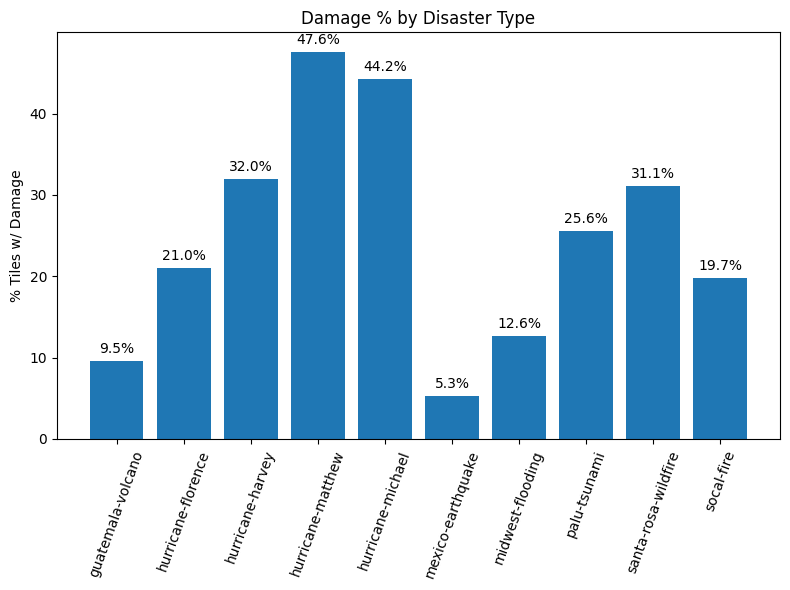

In [63]:
labels = []
values = []

for d in total_per_disaster:
    pct = (damage_per_disaster[d] / total_per_disaster[d]) * 100
    labels.append(d)
    values.append(pct)

plt.figure(figsize=(8, 6))
plt.bar(labels, values)
plt.xticks(rotation = 70)
plt.ylabel("% Tiles w/ Damage")
plt.title("Damage % by Disaster Type")

for i, v in enumerate(values):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center')

plt.tight_layout()
plt.show()